In [11]:
"""
Module: filtered_data.ipynb
Author: Dema N. Govalla
Date: November 12, 2023
Description: The file uses the data from features_train_test.csv to plot the different 
            features (Force, X-axis, Y-axis, Z-ais (Mag, Accel, Gyro)) for data representation. 
            It then passes the feature data through two smoothing filters, Average and Median filters
            and the results are plotted. Next, we save the filtered data into combined_sensorData.csv. 
            This CSV file is used to trains, tests, and analyzes the machine learning models - RFMN and TSC-LS. 
"""

import matplotlib.pyplot as plt
import numpy as np, pandas as pd

sensorData = pd.read_csv('2 column_features.csv')

# sensorData = pd.read_csv('features_train_test_copy.csv')
sensorData = sensorData.iloc[:,1:]


print(sensorData.head())
print(sensorData.shape)


   Time  Force  Mag_ave  Class
0  0.02      0   -722.0      1
1  0.04      0   -721.0      1
2  0.06      0   -719.5      1
3  0.08      0   -722.0      1
4   0.1      1   -720.0      1
(16000, 4)


In [12]:
numClasses = 4

classOne = sensorData.iloc[:int(1*(len(sensorData)/numClasses)), :]
# print(classOne)
print(classOne.shape)

classTwo = sensorData.iloc[int(1*(len(sensorData)/numClasses)):int(2*(len(sensorData)/numClasses)), :]
# print(classTwo)
print(classTwo.shape)

classThree = sensorData.iloc[int(2*(len(sensorData)/numClasses)):int(3*(len(sensorData)/numClasses)), :]
# print(classThree)
print(classThree.shape)

classFour = sensorData.iloc[int(3*(len(sensorData)/numClasses)):int(4*(len(sensorData)/numClasses)), :]
# print(classFour)
print(classFour.shape)


Time = np.arange(int(1*(len(sensorData)/numClasses)))

(4000, 4)
(4000, 4)
(4000, 4)
(4000, 4)


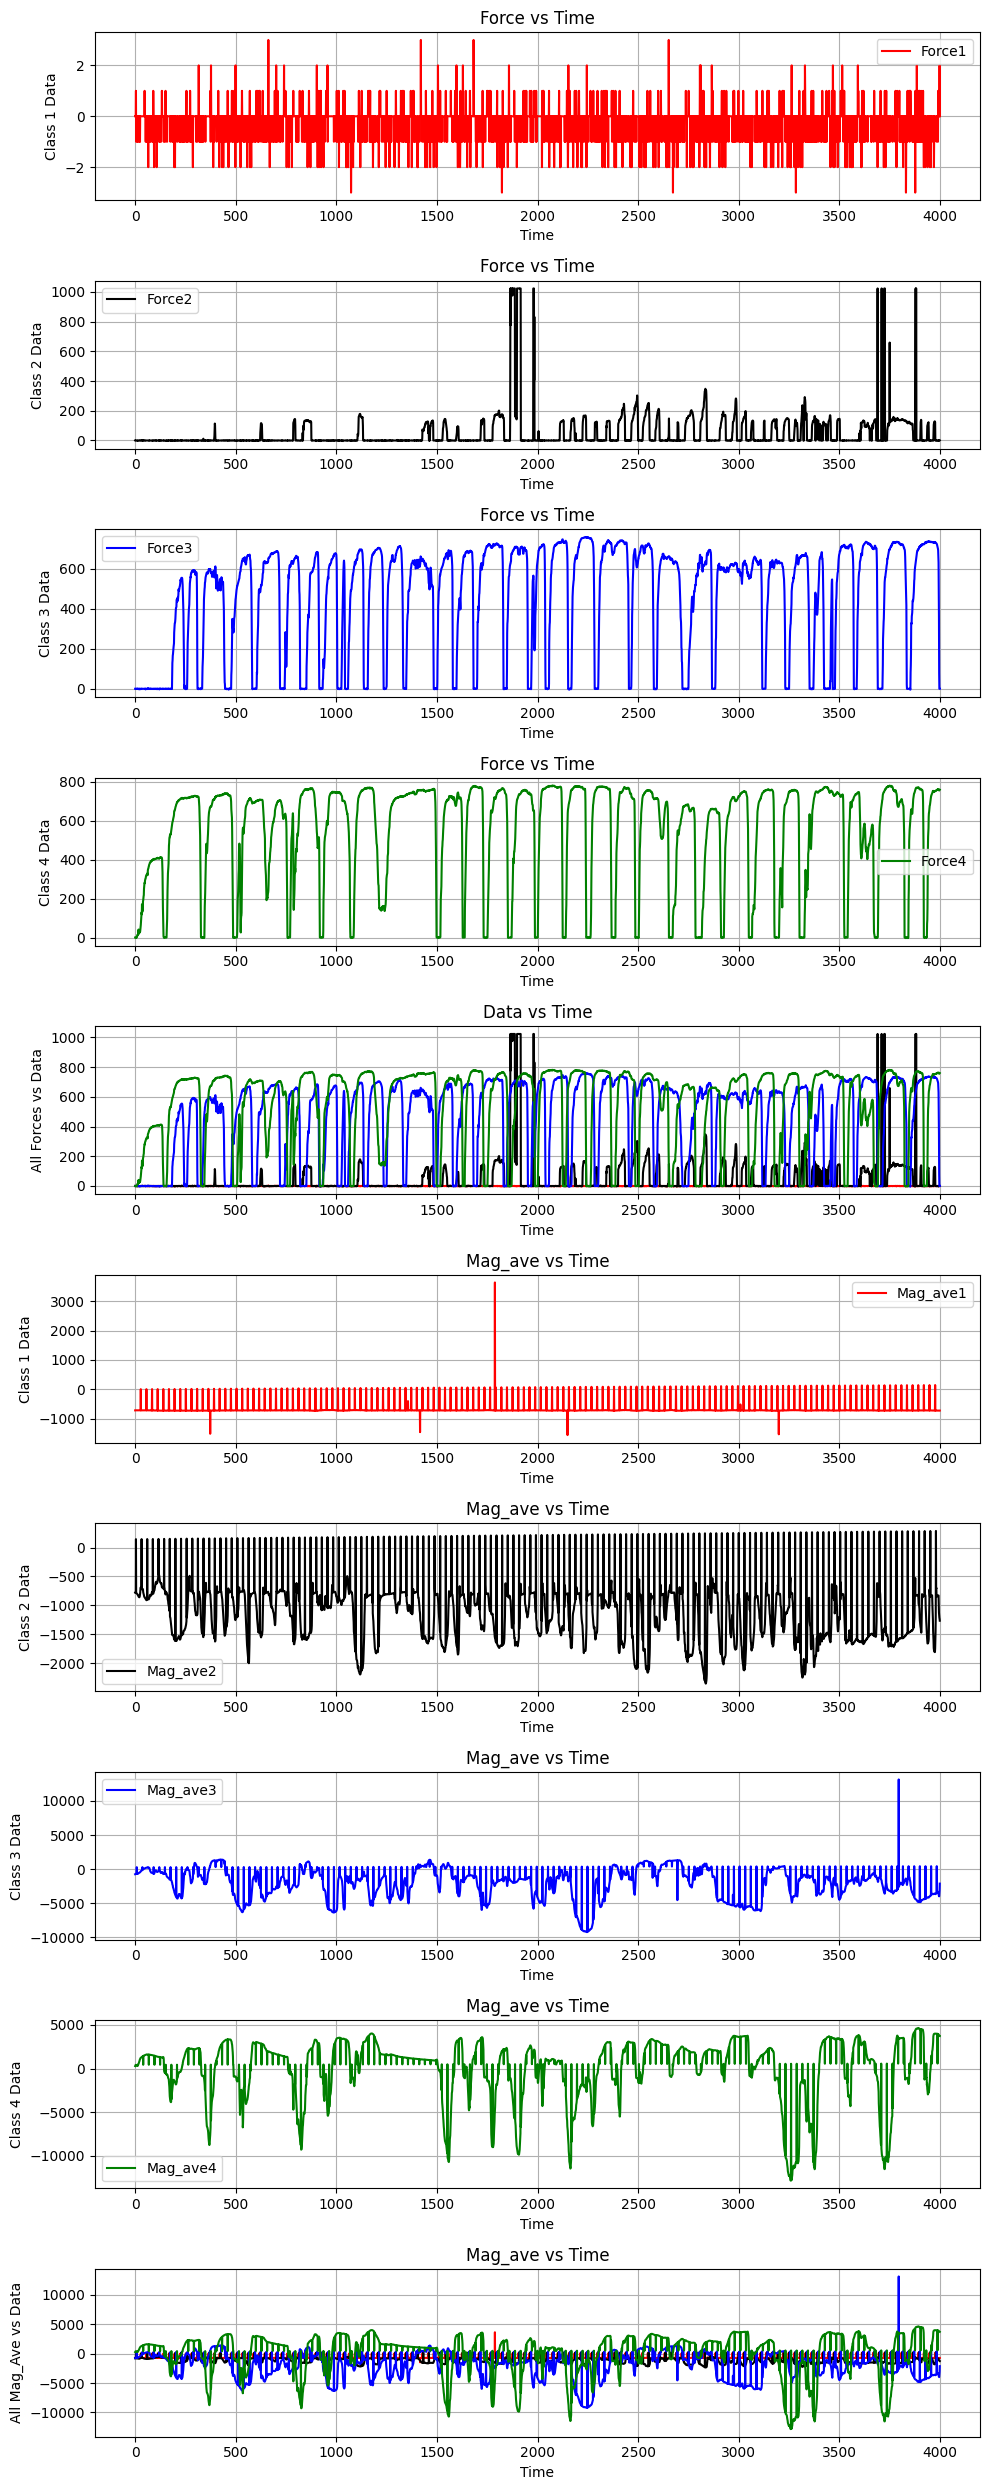

In [13]:
plt.figure("ArduinoDataAnalysis", figsize=(10, 25))

plt.subplot(10, 1, 1)
plt.plot(Time, classOne['Force'], label='Force1', color='r')
plt.xlabel('Time')
plt.ylabel('Class 1 Data')
plt.title('Force vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 2)
plt.plot(Time, classTwo['Force'], label='Force2', color='k')
plt.xlabel('Time')
plt.ylabel('Class 2 Data')
plt.title('Force vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 3)
plt.plot(Time, classThree['Force'], label='Force3', color='b')
plt.xlabel('Time')
plt.ylabel('Class 3 Data')
plt.title('Force vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 4)
plt.plot(Time, classFour['Force'], label='Force4', color='g')
plt.xlabel('Time')
plt.ylabel('Class 4 Data')
plt.title('Force vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 5)
plt.plot(Time, classOne['Force'], label='Force1', color='r')
plt.plot(Time, classTwo['Force'], label='Force2', color='k')
plt.plot(Time, classThree['Force'], label='Force3', color='b')
plt.plot(Time, classFour['Force'], label='Force4', color='g')
plt.xlabel('Time')
plt.ylabel('All Forces vs Data')
plt.title('Data vs Time')
plt.grid(True)



plt.subplot(10, 1, 6)
plt.plot(Time, classOne['Mag_ave'], label='Mag_ave1', color='r')
plt.xlabel('Time')
plt.ylabel('Class 1 Data')
plt.title('Mag_ave vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 7)
plt.plot(Time, classTwo['Mag_ave'], label='Mag_ave2', color='k')
plt.xlabel('Time')
plt.ylabel('Class 2 Data')
plt.title('Mag_ave vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 8)
plt.plot(Time, classThree['Mag_ave'], label='Mag_ave3', color='b')
plt.xlabel('Time')
plt.ylabel('Class 3 Data')
plt.title('Mag_ave vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 9)
plt.plot(Time, classFour['Mag_ave'], label='Mag_ave4', color='g')
plt.xlabel('Time')
plt.ylabel('Class 4 Data')
plt.title('Mag_ave vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 10)
plt.plot(Time, classOne['Mag_ave'], label='Mag_ave1', color='r')
plt.plot(Time, classTwo['Mag_ave'], label='Mag_ave2', color='k')
plt.plot(Time, classThree['Mag_ave'], label='Mag_ave3', color='b')
plt.plot(Time, classFour['Mag_ave'], label='Mag_ave4', color='g')
plt.xlabel('Time')
plt.ylabel('All Mag_Ave vs Data')
plt.title('Mag_ave vs Time')
plt.grid(True)


plt.tight_layout()
plt.show()


In [14]:
# Start applying smooth filters

# The running mean filter
def average_filter(data, window_size):
    ave_filter = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    return ave_filter

window_size = 50  # Set to frequency level. 
# ave_filt_time = np.arange(int(1*(len(sensorData)/numClasses)) - window_size + 1 )

# Time[window_size-1:]
# print(Time[window_size-1:])
# print(len(Time[window_size-1:]))


# print(ave_filt_time)
# print(len(ave_filt_time))


classOne_ave_filt_force = average_filter(classOne['Force'], window_size)
classOne_ave_filt_mag = average_filter(classOne['Mag_ave'], window_size)

print(classOne_ave_filt_force)
print(classOne_ave_filt_mag)
print(len(classOne_ave_filt_force))
print(len(classOne_ave_filt_mag))

classTwo_ave_filt_force = average_filter(classTwo['Force'], window_size)
classTwo_ave_filt_mag = average_filter(classTwo['Mag_ave'], window_size)

print(classTwo_ave_filt_force)
print(classTwo_ave_filt_mag)
print(len(classTwo_ave_filt_force))
print(len(classTwo_ave_filt_mag))

classThree_ave_filt_force = average_filter(classThree['Force'], window_size)
classThree_ave_filt_mag = average_filter(classThree['Mag_ave'], window_size)

print(classThree_ave_filt_force)
print(classThree_ave_filt_mag)
print(len(classThree_ave_filt_force))
print(len(classThree_ave_filt_mag))

classFour_ave_filt_force = average_filter(classFour['Force'], window_size)
classFour_ave_filt_mag = average_filter(classFour['Mag_ave'], window_size)

print(classFour_ave_filt_force)
print(classFour_ave_filt_mag)
print(len(classFour_ave_filt_force))
print(len(classFour_ave_filt_mag))





[-0.06 -0.06 -0.06 ... -0.22 -0.16 -0.16]
[-705.55 -705.51 -705.47 ... -692.57 -710.03 -710.13]
3951
3951
[-0.32 -0.32 -0.28 ... 20.62 20.64 20.66]
[ -755.04  -756.93  -758.85 ... -1057.77 -1067.93 -1077.68]
3951
3951
[-1.4000e-01 -1.4000e-01 -1.4000e-01 ...  6.8464e+02  6.6994e+02
  6.5526e+02]
[ -347.39  -329.51  -311.88 ... -3496.12 -3477.84 -3440.15]
3951
3951
[ 88.58  94.56 100.6  ... 742.8  744.66 746.3 ]
[ 921.6   947.29  971.64 ... 2681.67 2791.27 2895.72]
3951
3951


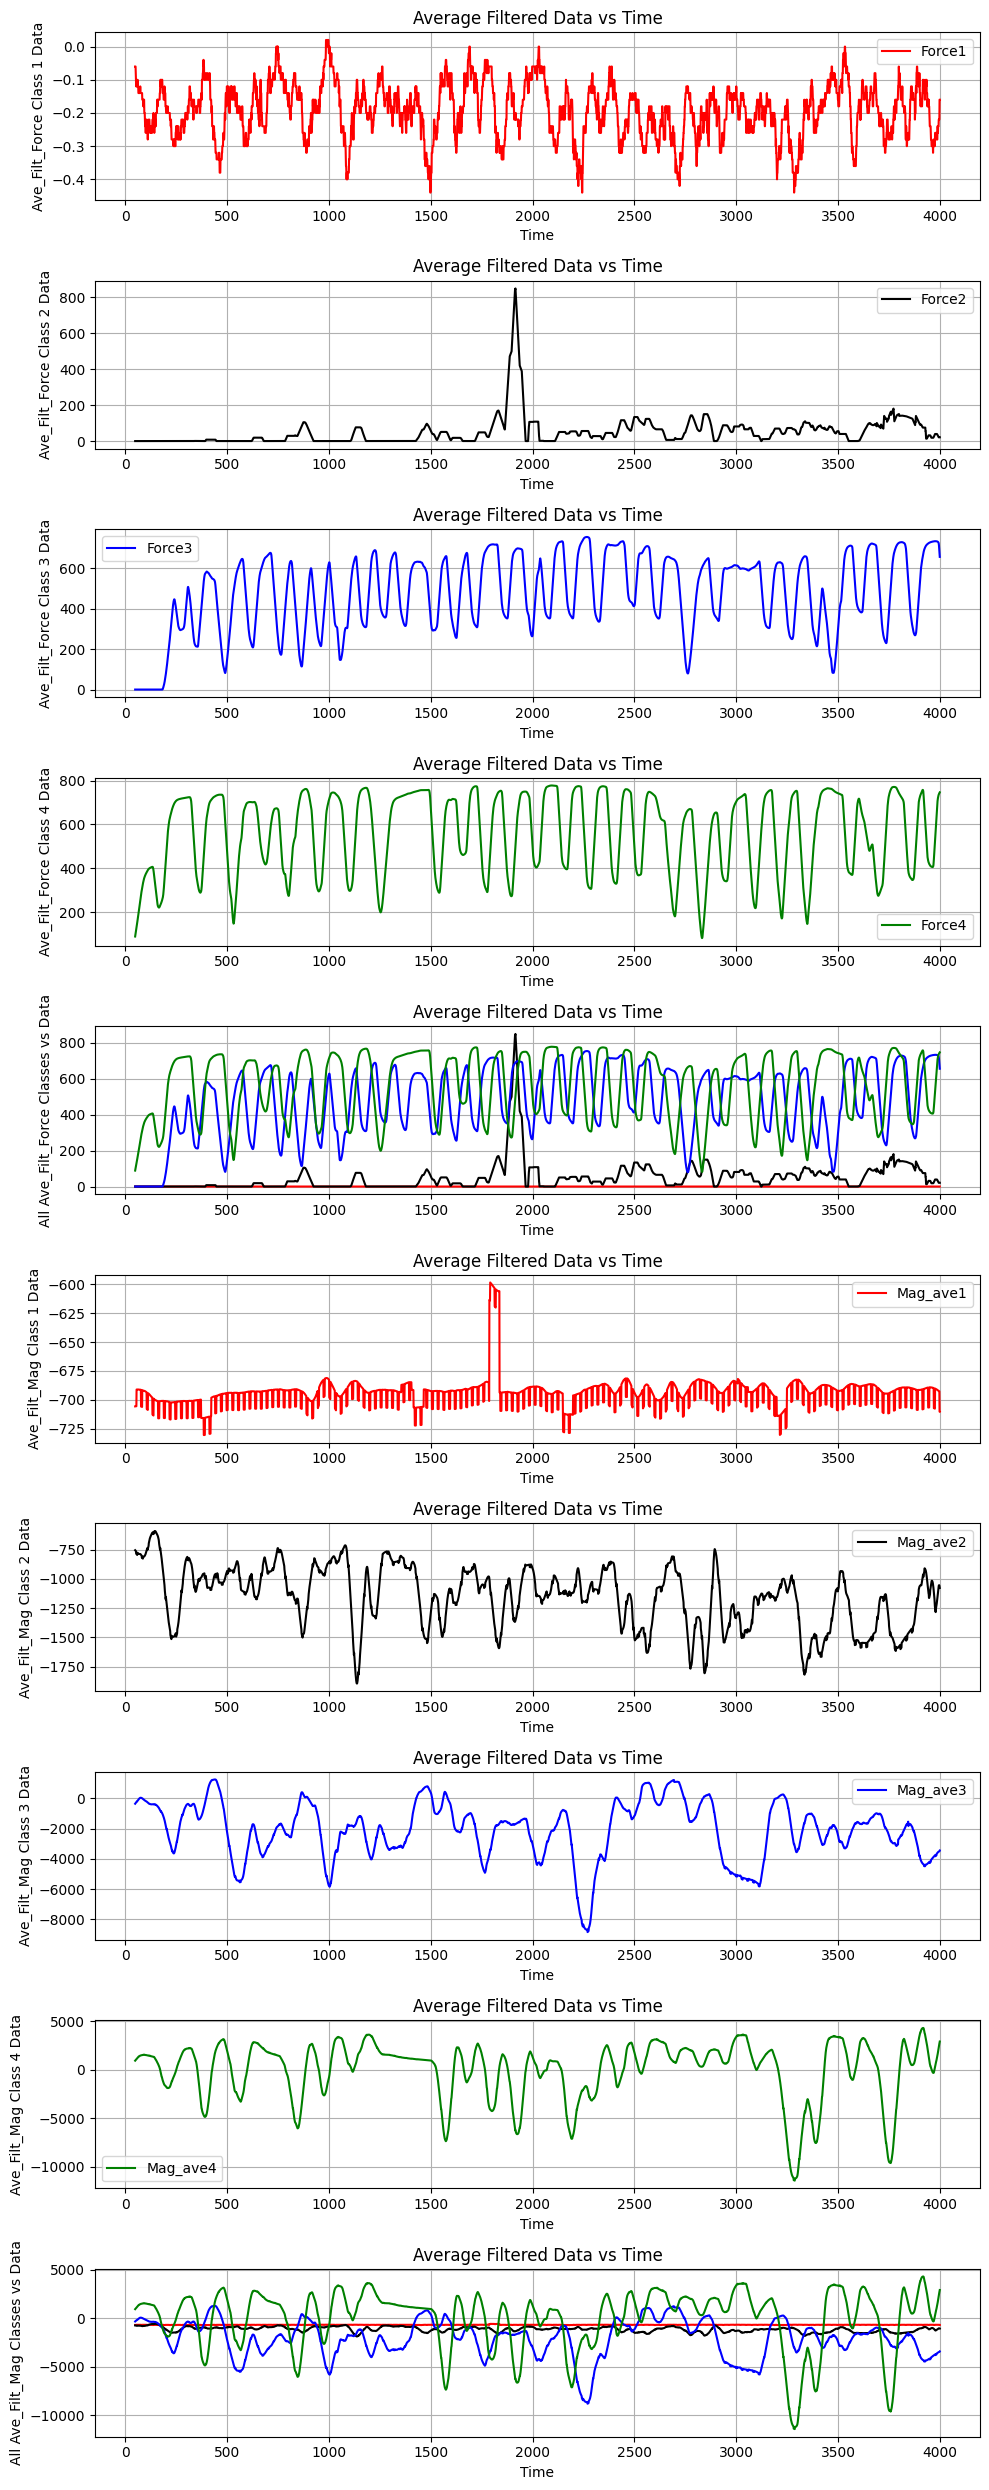

In [15]:
plt.figure("AverageFilteredDataAnalysis", figsize=(10, 25))


plt.subplot(10, 1, 1)
plt.plot(Time[window_size-1:], classOne_ave_filt_force, label='Force1', color='r')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 2)
plt.plot(Time[window_size-1:], classTwo_ave_filt_force, label='Force2', color='k')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 3)
plt.plot(Time[window_size-1:], classThree_ave_filt_force, label='Force3', color='b')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 4)
plt.plot(Time[window_size-1:], classFour_ave_filt_force, label='Force4', color='g')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 5)
plt.plot(Time[window_size-1:], classOne_ave_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classTwo_ave_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classThree_ave_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classFour_ave_filt_force, label='Force4', color='g')
plt.xlabel('Time')
plt.ylabel('All Ave_Filt_Force Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)



plt.subplot(10, 1, 6)
plt.plot(Time[window_size-1:], classOne_ave_filt_mag, label='Mag_ave1', color='r')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Mag Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 7)
plt.plot(Time[window_size-1:], classTwo_ave_filt_mag, label='Mag_ave2', color='k')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Mag Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 8)
plt.plot(Time[window_size-1:], classThree_ave_filt_mag, label='Mag_ave3', color='b')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Mag Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 9)
plt.plot(Time[window_size-1:], classFour_ave_filt_mag, label='Mag_ave4', color='g')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Mag Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 10)
plt.plot(Time[window_size-1:], classOne_ave_filt_mag, label='Mag_ave1', color='r')
plt.plot(Time[window_size-1:], classTwo_ave_filt_mag, label='Mag_ave2', color='k')
plt.plot(Time[window_size-1:], classThree_ave_filt_mag, label='Mag_ave3', color='b')
plt.plot(Time[window_size-1:], classFour_ave_filt_mag, label='Mag_ave4', color='g')
plt.xlabel('Time')
plt.ylabel('All Ave_Filt_Mag Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()




In [16]:
# The moving median filter
def median_filter(data, window_size):
    return np.array([np.median(data[i:i+window_size]) for i in range(len(data)-window_size+1)])


classOne_med_filt_force = median_filter(classOne['Force'], window_size)
classOne_med_filt_mag = median_filter(classOne['Mag_ave'], window_size)

print(classOne_med_filt_force)
print(classOne_med_filt_mag)
print(len(classOne_med_filt_force))
print(len(classOne_med_filt_mag))

classTwo_med_filt_force = median_filter(classTwo['Force'], window_size)
classTwo_med_filt_mag = median_filter(classTwo['Mag_ave'], window_size)

classThree_med_filt_force = median_filter(classThree['Force'], window_size)
classThree_med_filt_mag = median_filter(classThree['Mag_ave'], window_size)


classFour_med_filt_force = median_filter(classFour['Force'], window_size)
classFour_med_filt_mag = median_filter(classFour['Mag_ave'], window_size)
print(classFour_med_filt_force)
print(classFour_med_filt_mag)






[0. 0. 0. ... 0. 0. 0.]
[-720.   -720.   -720.   ... -727.25 -727.5  -727.5 ]
3951
3951
[ 39.   41.5  46.  ... 753.  753.  753.5]
[1030.   1107.25 1168.75 ... 3863.75 3863.75 3863.75]


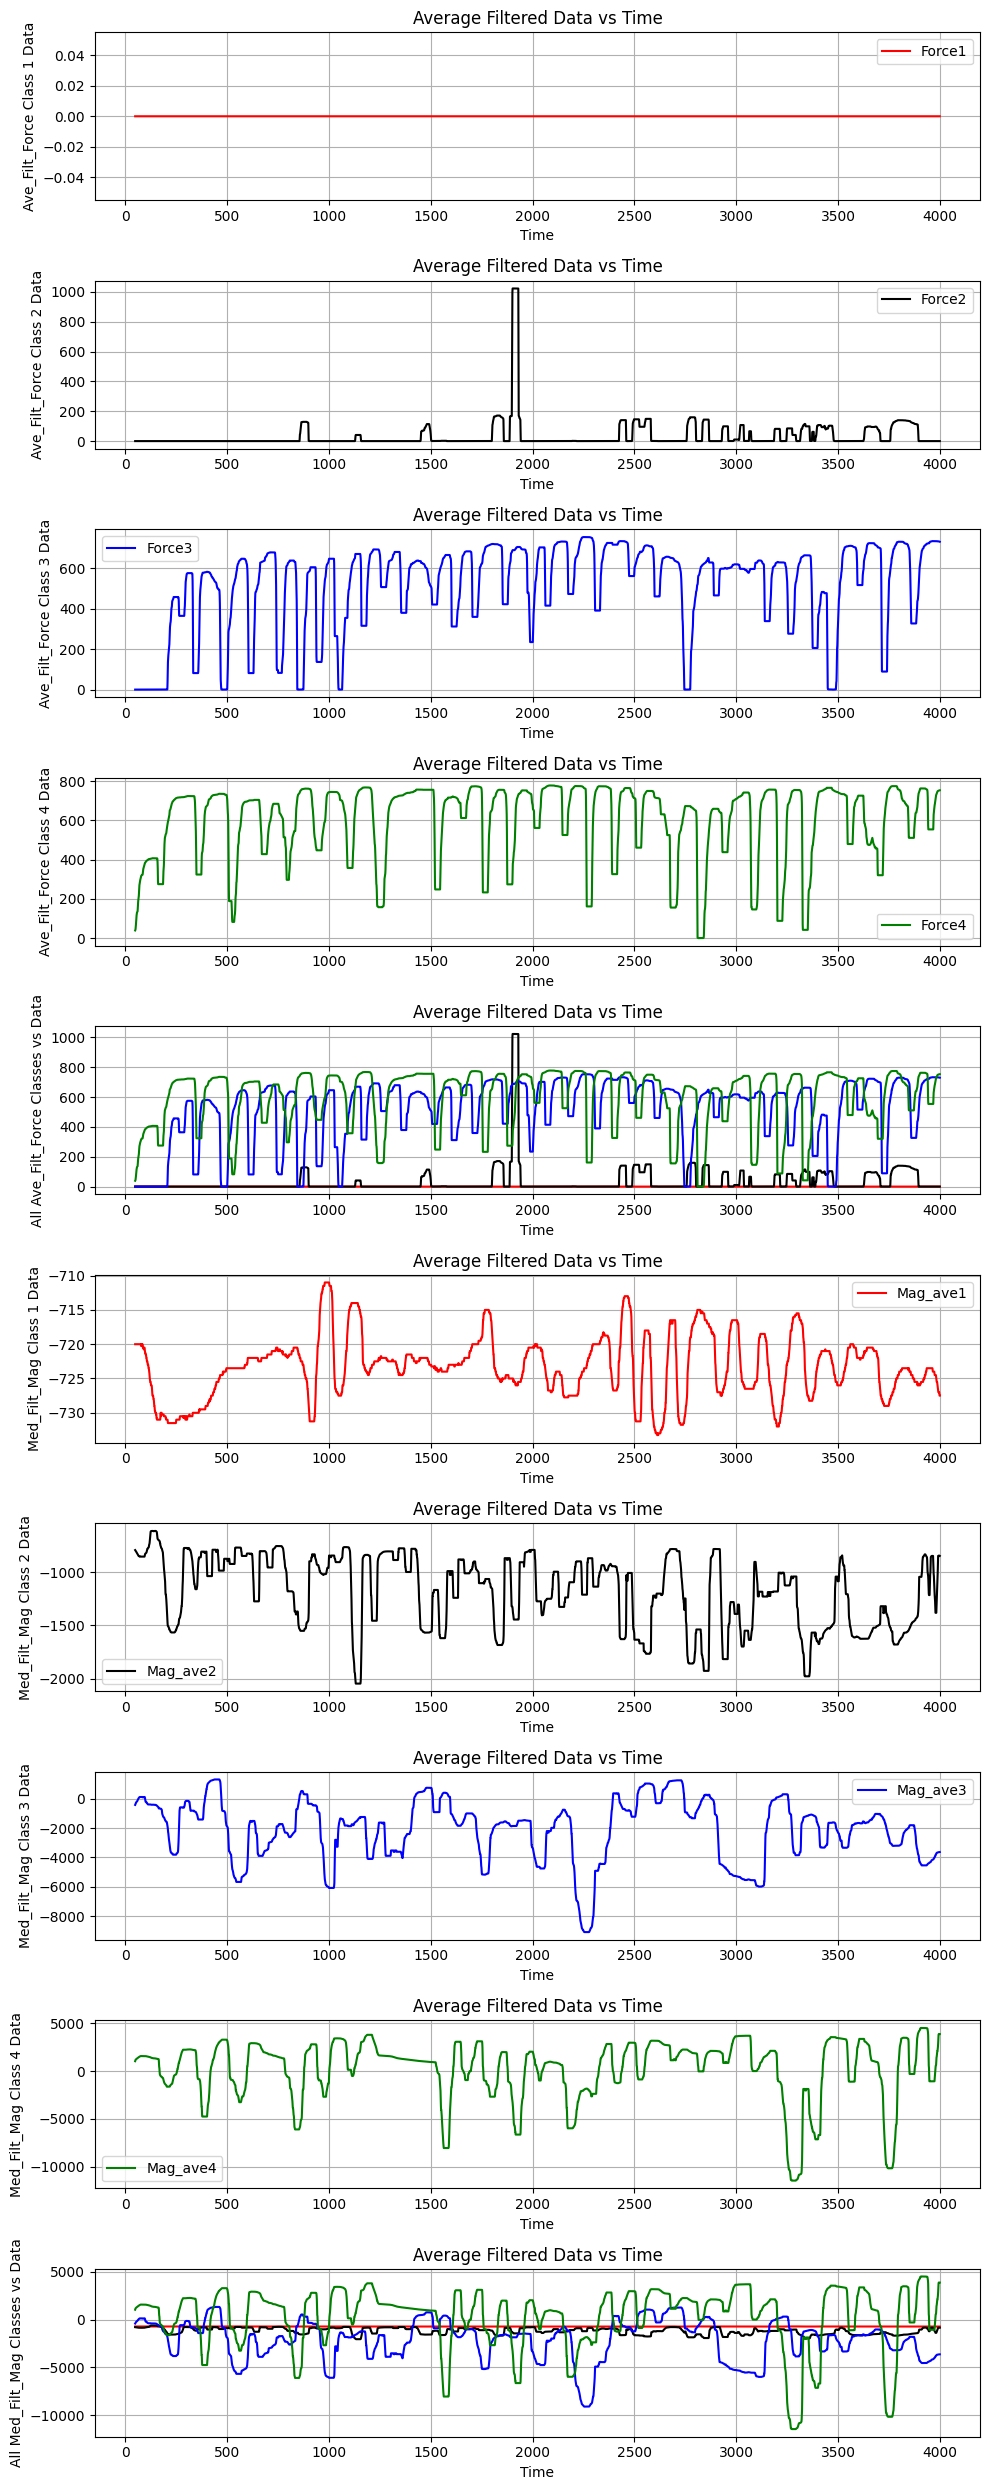

In [17]:
plt.figure("MedianFilteredDataAnalysis", figsize=(10, 25))

plt.subplot(10, 1, 1)
plt.plot(Time[window_size-1:], classOne_med_filt_force, label='Force1', color='r')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 2)
plt.plot(Time[window_size-1:], classTwo_med_filt_force, label='Force2', color='k')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 3)
plt.plot(Time[window_size-1:], classThree_med_filt_force, label='Force3', color='b')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 4)
plt.plot(Time[window_size-1:], classFour_med_filt_force, label='Force4', color='g')
plt.xlabel('Time')
plt.ylabel('Ave_Filt_Force Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 5)
plt.plot(Time[window_size-1:], classOne_med_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classTwo_med_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classThree_med_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classFour_med_filt_force, label='Force4', color='g')
plt.xlabel('Time')
plt.ylabel('All Ave_Filt_Force Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)


plt.subplot(10, 1, 6)
plt.plot(Time[window_size-1:], classOne_med_filt_mag, label='Mag_ave1', color='r')
plt.xlabel('Time')
plt.ylabel('Med_Filt_Mag Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 7)
plt.plot(Time[window_size-1:], classTwo_med_filt_mag, label='Mag_ave2', color='k')
plt.xlabel('Time')
plt.ylabel('Med_Filt_Mag Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 8)
plt.plot(Time[window_size-1:], classThree_med_filt_mag, label='Mag_ave3', color='b')
plt.xlabel('Time')
plt.ylabel('Med_Filt_Mag Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 9)
plt.plot(Time[window_size-1:], classFour_med_filt_mag, label='Mag_ave4', color='g')
plt.xlabel('Time')
plt.ylabel('Med_Filt_Mag Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)
plt.subplot(10, 1, 10)
plt.plot(Time[window_size-1:], classOne_med_filt_mag, label='Mag_ave1', color='r')
plt.plot(Time[window_size-1:], classTwo_med_filt_mag, label='Mag_ave2', color='k')
plt.plot(Time[window_size-1:], classThree_med_filt_mag, label='Mag_ave3', color='b')
plt.plot(Time[window_size-1:], classFour_med_filt_mag, label='Mag_ave4', color='g')
plt.xlabel('Time')
plt.ylabel('All Med_Filt_Mag Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()




In [18]:
combined_ave_filt_force = np.concatenate((classOne_ave_filt_force,classTwo_ave_filt_force,
                                          classThree_ave_filt_force,classFour_ave_filt_force))
print(combined_ave_filt_force)


combined_ave_filt_mag = np.concatenate((classOne_ave_filt_mag,classTwo_ave_filt_mag,
                                          classThree_ave_filt_mag,classFour_ave_filt_mag))
print(combined_ave_filt_mag)




[-6.0000e-02 -6.0000e-02 -6.0000e-02 ...  7.4280e+02  7.4466e+02
  7.4630e+02]
[-705.55 -705.51 -705.47 ... 2681.67 2791.27 2895.72]


In [19]:
combined_med_filt_force = np.concatenate((classOne_med_filt_force,classTwo_med_filt_force,
                                          classThree_med_filt_force,classFour_med_filt_force))
print(combined_med_filt_force)
print(len(combined_med_filt_force))



combined_med_filt_mag = np.concatenate((classOne_med_filt_mag,classTwo_med_filt_mag,
                                          classThree_med_filt_mag,classFour_med_filt_mag))
print(combined_med_filt_mag)



[  0.    0.    0.  ... 753.  753.  753.5]
15804
[-720.   -720.   -720.   ... 3863.75 3863.75 3863.75]


In [20]:
new_sensorData = pd.DataFrame({
    'ave_filt_force': combined_ave_filt_force,
    'med_filt_force': combined_med_filt_force,
    
    'ave_filt_mag': combined_ave_filt_mag,
    'med_filt_mag': combined_med_filt_mag,

})

split = len(classOne_ave_filt_force)
print(split)

new_sensorData['Class'] = 0
new_sensorData.loc[0:(1*split)-1, 'Class'] = 1
new_sensorData.loc[(1*split):(2*split)-1, 'Class'] = 2
new_sensorData.loc[(2*split):(3*split)-1, 'Class'] = 3
new_sensorData.loc[(3*split):(4*split)-1, 'Class'] = 4

new_sensorData.to_csv('2 column_combined_sensorData.csv', index=False)



3951
